In [34]:
import vitaldb
import numpy as np
import pandas as pd
import os
import scipy.signal
import matplotlib.pyplot as plt
import random
import itertools as it
import numpy as np
from matplotlib import pyplot as plt
import keras.models
import tensorflow as tf
from keras.models import Model

SRATE = 128  # in hz
SEGLEN = 4 * SRATE  # samples
BATCH_SIZE = 1024
MAX_CASES = 100


#reads two CSV files from vitaldb
df_trks = pd.read_csv("https://api.vitaldb.net/trks") #track information
df_cases = pd.read_csv("https://api.vitaldb.net/cases") #patient information

#column order when loading data
EEG = 0 #EEG
SEVO = 1 #Sevoflurane, an anesthetic
BIS = 2 #Bispectral Index, a measure of anesthesia depth

#creates a set of case IDs that meet specific criteria (exclusion and inclusion criteria
caseids = set(df_cases.loc[df_cases['age'] > 18, 'caseid']) &\
    set(df_trks.loc[df_trks['tname'] == 'BIS/EEG1_WAV', 'caseid']) &\
    set(df_trks.loc[df_trks['tname'] == 'BIS/BIS', 'caseid']) &\
    set(df_trks.loc[df_trks['tname'] == 'Primus/EXP_SEVO', 'caseid'])

#initializes empty lists to store:
x = []  #stores EEG data
y = []  # stores anesthesia data
b = []  # stores bis data
c = []  # stores caseids
icase = 0  # number of cases loaded so far


#iterates through each case ID that passed the initial inclusion criteria.
for caseid in caseids:
    
    #report/check: prints the current case ID and progress (current case number / maximum cases)
    print('loading {} ({}/{})'.format(caseid, icase, MAX_CASES), end='...', flush=True)

    #Additional exclusion criteria: checks for the presence of certain drugs or gases
    if np.any(vitaldb.load_case(caseid, 'Orchestra/PPF20_CE') > 0.2):
        continue
    if np.any(vitaldb.load_case(caseid, 'Primus/EXP_DES') > 1):
        continue
    if np.any(vitaldb.load_case(caseid, 'Primus/FEN2O') > 2):
        continue
    if np.any(vitaldb.load_case(caseid, 'Orchestra/RFTN50_CE') > 0.2):
        continue
    
    
    #Extracts Data:loads data for a specific case (patient) and a particular track (parameter)
    #Returns a numpy array containing the values for the requested tracks
    vals = vitaldb.load_case(caseid, ['BIS/EEG1_WAV', 'Primus/EXP_SEVO', 'BIS/BIS'], 1 / SRATE)

    if np.nanmax(vals[:, SEVO]) < 1:
        print('all sevo <= 1')
        continue


    # Purpose: finding the age of the patient with the specific caseid in the df_cases DataFrame
    age = df_cases.loc[df_cases['caseid'] == caseid, 'age'].values[0]

    vals[:, SEVO] /= 1.80 * 10 ** (-0.00269 * (age - 40))

    if not np.any(vals[:, BIS] > 0):
        print('all bis <= 0')
        continue

    valid_bis_idx = np.where(vals[:, BIS] > 0)[0]
    first_bis_idx = valid_bis_idx[0]
    last_bis_idx = valid_bis_idx[-1]
    vals = vals[first_bis_idx:last_bis_idx + 1, :]

    #Ensures the data spans at least 30 minutes (1800 seconds * SRATE)
    if len(vals) < 1800 * SRATE: 
        print('{} len < 30 min'.format(caseid))
        continue

    # Purpose: fills in missing values (gaps of up to 5 seconds) in the sevo concentration-> preserves the original values where data exists and only fills short gaps
    vals[:, SEVO:] = pd.DataFrame(vals[:, SEVO:]).ffill(limit=5 * SRATE).values

    #Stores the current length of y
    oldlen = len(y)

    #iterates through the data at intervals of SRATE starting from SEGLEN
    #start, stop, and step paramaters
    for irow in range(SEGLEN, len(vals), SRATE):
        bis = vals[irow, BIS]
        mac = vals[irow, SEVO]
        if np.isnan(bis) or np.isnan(mac) or bis == 0:
            continue
        eeg = vals[irow - SEGLEN:irow, EEG]
        x.append(eeg)
        y.append(mac)
        b.append(bis)
        c.append(caseid)
        
  # Increments case counter and prints progress information
    icase += 1
    print('{} samples read -> total {} samples ({}/{})'.format(len(y) - oldlen, len(y), icase, MAX_CASES))
    if icase >= MAX_CASES:
        break

# Converts Lists to NumPy Arrays
x = np.array(x)
y = np.array(y)
b = np.array(b)
c = np.array(c)


# exclude segments
print('invalid samples...', end='', flush=True)
valid_mask = ~(np.max(np.isnan(x), axis=1) > 0) # Identifies rows in x that don't contain any NaN values
valid_mask &= (np.nanmax(x, axis=1) - np.nanmin(x, axis=1) > 12)  #Ensures the range of values in each row of x is greater than 12 
valid_mask &= (np.nanmax(np.abs(x), axis=1) < 100)  # Excludes rows where the absolute maximum value exceeds 100 

x = x[valid_mask]
y = y[valid_mask]
b = b[valid_mask]
c = c[valid_mask]

caseids = list(np.unique(c))

loading 1 (0/100)...loading 2 (0/100)...10381 samples read -> total 10381 samples (1/100)
loading 3 (1/100)...loading 4 (1/100)...14367 samples read -> total 24748 samples (2/100)
loading 5 (2/100)...loading 10 (2/100)...14509 samples read -> total 39257 samples (3/100)
loading 12 (3/100)...21126 samples read -> total 60383 samples (4/100)
loading 18 (4/100)...all bis <= 0
loading 19 (4/100)...loading 20 (4/100)...loading 21 (4/100)...8087 samples read -> total 68470 samples (5/100)
loading 24 (5/100)...3599 samples read -> total 72069 samples (6/100)
loading 25 (6/100)...9665 samples read -> total 81734 samples (7/100)
loading 26 (7/100)...loading 27 (7/100)...11541 samples read -> total 93275 samples (8/100)
loading 30 (8/100)...loading 33 (8/100)...2797 samples read -> total 96072 samples (9/100)
loading 34 (9/100)...loading 35 (9/100)...loading 38 (9/100)...loading 43 (9/100)...9689 samples read -> total 105761 samples (10/100)
loading 44 (10/100)...loading 49 (10/100)...6768 sampl

/var/folders/lh/9hv0y54n6z790wj1yxy04d2c0000gn/T/ipykernel_4328/2448465220.py:125: RuntimeWarning: All-NaN slice encountered
  valid_mask &= (np.nanmax(x, axis=1) - np.nanmin(x, axis=1) > 12)  #Ensures the range of values in each row of x is greater than 12
/var/folders/lh/9hv0y54n6z790wj1yxy04d2c0000gn/T/ipykernel_4328/2448465220.py:126: RuntimeWarning: All-NaN slice encountered
  valid_mask &= (np.nanmax(np.abs(x), axis=1) < 100)  # Excludes rows where the absolute maximum value exceeds 100


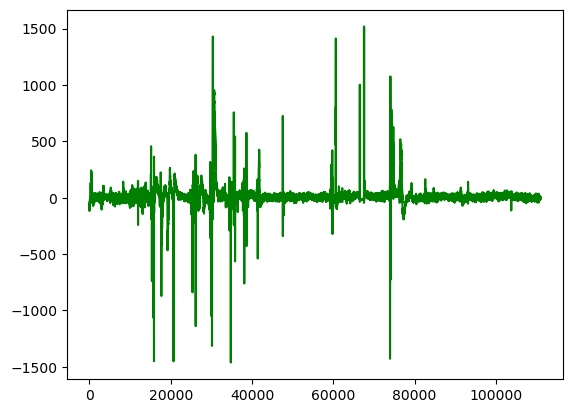

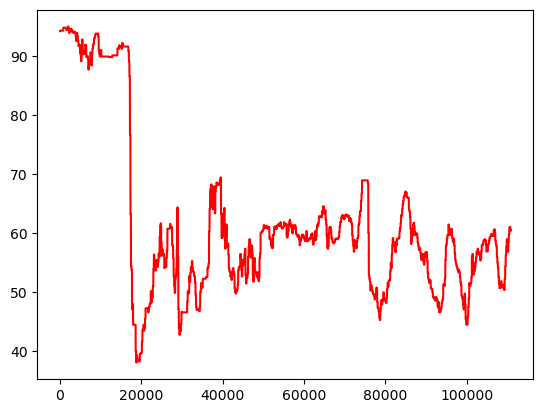

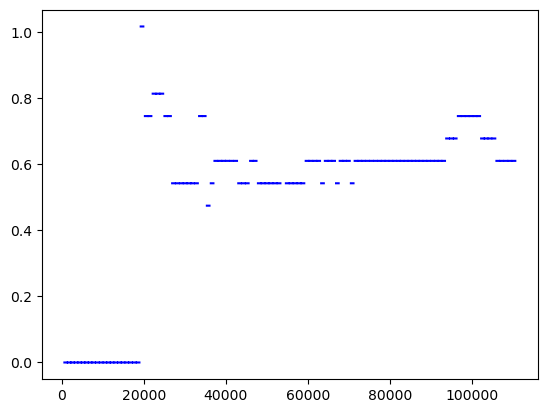

In [71]:
#visualizing the tracks the model uses
#not final- went through most inclusion/exclusion criteria but not valid_mask

eeg = vals[:,EEG]
bis = vals[:,BIS]
mac = vals[:,SEVO]

#can put in different indexes to display different data
plt.plot(eeg[100:111000], color='g')
plt.show()
plt.plot(bis[100:111000], color='r')
plt.show()
plt.plot(mac[100:111000], color='b')
plt.show()

In [75]:
#This is the final data the model uses (after all the exclusion/inclusion criteria):

print("x type: " + str(x.dtype))
print("x shape: " + str(x.shape))
print("x size: " + str(x.size))
print("")

print("y type: "+  str(y.dtype))
print("y shape: " + str(y.shape))
print("y size: " + str(y.size))
print("")

print("b type: " + str(b.dtype))
print("b shape: " + str(b.shape))
print("b size: " + str(b.size))
print("")

print("c type: " + str(c.dtype))
print("c shape: " + str(c.shape))
print("c size: " + str(c.size))
print("")

# Split dataset into training and testing data
ntest = max(1, int(len(caseids) * 0.2)) #Sets the number of test cases to 20% of the total cases
caseids_train = caseids[ntest:]
caseids_test = caseids[:ntest]

#Creates boolean masks for training and testing data based on case ID
train_mask = np.isin(c, caseids_train)
test_mask = np.isin(c, caseids_test)

#Applies Masks to Data
x_train = x[train_mask]
y_train = y[train_mask]
x_test = x[test_mask]
y_test = y[test_mask]
b_test = b[test_mask]
c_test = c[test_mask]

print("x_train type: " + str(x_train.dtype))
print("x_train shape: " + str(x_train.shape))
print("x size: " + str(x_train.size))
print("")

print("y_train type: "+  str(y_train.dtype))
print("y_train shape: " + str(y_train.shape))
print("y_traib size: " + str(y_train.size))
print("")

x type: float64
x shape: (713641, 512)
x size: 365384192

y type: float64
y shape: (713641,)
y size: 713641

b type: float64
b shape: (713641,)
b size: 713641

c type: int64
c shape: (713641,)
c size: 713641

x_train type: float64
x_train shape: (548428, 512)
x size: 280795136

y_train type: float64
y_train shape: (548428,)
y_traib size: 548428

